<a href="https://colab.research.google.com/github/keyonai/Time-Series-Anomaly-Detection-Pump-Sensor-Data-/blob/main/Time_Series_Anomaly_Detection_(Pump_Sensor_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub
import kagglehub
import os
import pandas as pd
import numpy as np
#setup and load data

path = kagglehub.dataset_download("nphantawee/pump-sensor-data")
print("Dataset downloaded to:", path)
print(os.listdir(path))  # confirm the actual filename(s) inside

Using Colab cache for faster access to the 'pump-sensor-data' dataset.
Dataset downloaded to: /kaggle/input/pump-sensor-data
['sensor.csv']


In [ ]:
csv_path = os.path.join(path, "sensor.csv")
df = pd.read_csv(csv_path, parse_dates=["timestamp"])
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

null_frac = df.isnull().mean()
df = df.drop(columns=null_frac[null_frac > 0.3].index.tolist())

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
df[sensor_cols] = df[sensor_cols].fillna(method="ffill").fillna(method="bfill")

failure_times = df.loc[df["machine_status"] == "BROKEN", "timestamp"]
print(f"{len(failure_times)} known failures in the dataset")
print(df.shape)
df.head()

/tmp/ipykernel_6612/2474648779.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[sensor_cols] = df[sensor_cols].fillna(method="ffill").fillna(method="bfill")


7 known failures in the dataset
(220320, 52)


,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,machine_status
0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,NORMAL
1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,NORMAL
2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,203.7037,NORMAL
3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,203.1250,NORMAL
4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,201.3889,NORMAL


In [ ]:
#step 2-Isolation forest pipline(rolling-window features)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

window = 60
feat_df = df[sensor_cols].copy()
for col in sensor_cols:
    feat_df[f"{col}_rollmean"] = df[col].rolling(window).mean()
    feat_df[f"{col}_rollstd"] = df[col].rolling(window).std()

feat_df = feat_df.dropna().reset_index(drop=True)
meta = df.iloc[window-1:].reset_index(drop=True)

scaler = StandardScaler()
X = scaler.fit_transform(feat_df)

iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
iso.fit(X)

results = meta[["timestamp", "machine_status"]].copy()
results["iso_score"] = -iso.decision_function(X)
results["iso_anomaly"] = iso.predict(X) == -1

/tmp/ipykernel_6612/1773389757.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feat_df[f"{col}_rollstd"] = df[col].rolling(window).std()


In [ ]:
#step 3-LSTM Autoencoder pipeline
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

seq_len = 30
normal_df = df[df["machine_status"] == "NORMAL"][sensor_cols]

scaler2 = StandardScaler()
normal_scaled = scaler2.fit_transform(normal_df)
full_scaled = scaler2.transform(df[sensor_cols])

def make_sequences(arr, seq_len):
    return np.array([arr[i:i+seq_len] for i in range(len(arr) - seq_len)])

train_seqs = make_sequences(normal_scaled, seq_len)
all_seqs = make_sequences(full_scaled, seq_len)

train_tensor = torch.tensor(train_seqs, dtype=torch.float32)
loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)
n_features = train_tensor.shape[2]

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden=32, latent=8):
        super().__init__()
        self.enc = nn.LSTM(n_features, hidden, batch_first=True)
        self.enc2 = nn.LSTM(hidden, latent, batch_first=True)
        self.dec = nn.LSTM(latent, hidden, batch_first=True)
        self.dec2 = nn.LSTM(hidden, n_features, batch_first=True)

    def forward(self, x):
        out, _ = self.enc(x)
        out, (h, _) = self.enc2(out)
        latent_rep = h[-1].unsqueeze(1).repeat(1, x.shape[1], 1)
        out, _ = self.dec(latent_rep)
        out, _ = self.dec2(out)
        return out

model = LSTMAutoencoder(n_features).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(10):
    total_loss = 0
    for (batch,) in loader:
        batch = batch.to(device)
        opt.zero_grad()
        recon = model(batch)
        loss = loss_fn(recon, batch)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"epoch {epoch+1}, loss {total_loss/len(loader):.4f}")

model.eval()
batch_size = 512
all_errors = []
all_tensor = torch.tensor(all_seqs, dtype=torch.float32)

with torch.no_grad():
    for i in range(0, len(all_tensor), batch_size):
        batch = all_tensor[i:i+batch_size].to(device)
        recon = model(batch)
        err = ((recon - batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
        all_errors.append(err)

lstm_errors = np.concatenate(all_errors)

lstm_meta = df.iloc[seq_len:].reset_index(drop=True)
lstm_results = lstm_meta[["timestamp", "machine_status"]].copy()
lstm_results["lstm_score"] = lstm_errors
threshold = np.percentile(lstm_errors, 95)
lstm_results["lstm_anomaly"] = lstm_errors > threshold

print(lstm_results["lstm_anomaly"].sum(), "anomalies flagged out of", len(lstm_results))


Using device: cuda
epoch 1, loss 0.5525
epoch 2, loss 0.4918
epoch 3, loss 0.4708
epoch 4, loss 0.4560
epoch 5, loss 0.4474
epoch 6, loss 0.4417
epoch 7, loss 0.4373
epoch 8, loss 0.4340
epoch 9, loss 0.4325
epoch 10, loss 0.4299
11015 anomalies flagged out of 220290


In [ ]:
#step 4-Align both outputs to a common timeline
#The two models drop different numbers of leading rows (window=60 vs seq_len=30), so merge on timestamp.
comparison = results.merge(
    lstm_results[["timestamp", "lstm_score", "lstm_anomaly"]],
    on="timestamp", how="inner"
)

In [ ]:
#step 5-Comparison metrics
#Two things actually matter for this problem: lead time (how far in advance did it warn you?) and false positive rate (how noisy is it during normal operation?).
def evaluate(results, score_col, anomaly_col, failure_times, lookback_hours=6):
    lead_times = []
    for t in failure_times:
        window_before = results[(results["timestamp"] >= t - pd.Timedelta(hours=lookback_hours)) &
                                 (results["timestamp"] <= t)]
        flagged = window_before[window_before[anomaly_col]]
        if len(flagged) > 0:
            lead = (t - flagged["timestamp"].min()).total_seconds() / 3600
            lead_times.append(lead)
        else:
            lead_times.append(0)

    normal_mask = results["machine_status"] == "NORMAL"
    fpr = results.loc[normal_mask, anomaly_col].mean()

    caught = sum(l > 0 for l in lead_times)
    return {
        "failures_caught": f"{caught}/{len(failure_times)}",
        "avg_lead_time_hrs": np.mean([l for l in lead_times if l > 0]) if caught else 0,
        "false_positive_rate_on_normal": fpr
    }

iso_metrics = evaluate(comparison, "iso_score", "iso_anomaly", failure_times, lookback_hours=48)
lstm_metrics = evaluate(comparison, "lstm_score", "lstm_anomaly", failure_times, lookback_hours=48)

print("Isolation Forest:", iso_metrics)
print("LSTM Autoencoder:", lstm_metrics)

Isolation Forest: {'failures_caught': '1/7', 'avg_lead_time_hrs': np.float64(47.4), 'false_positive_rate_on_normal': np.float64(0.025158302434188467)}
LSTM Autoencoder: {'failures_caught': '3/7', 'avg_lead_time_hrs': np.float64(13.677777777777777), 'false_positive_rate_on_normal': np.float64(0.0030032510922017525)}


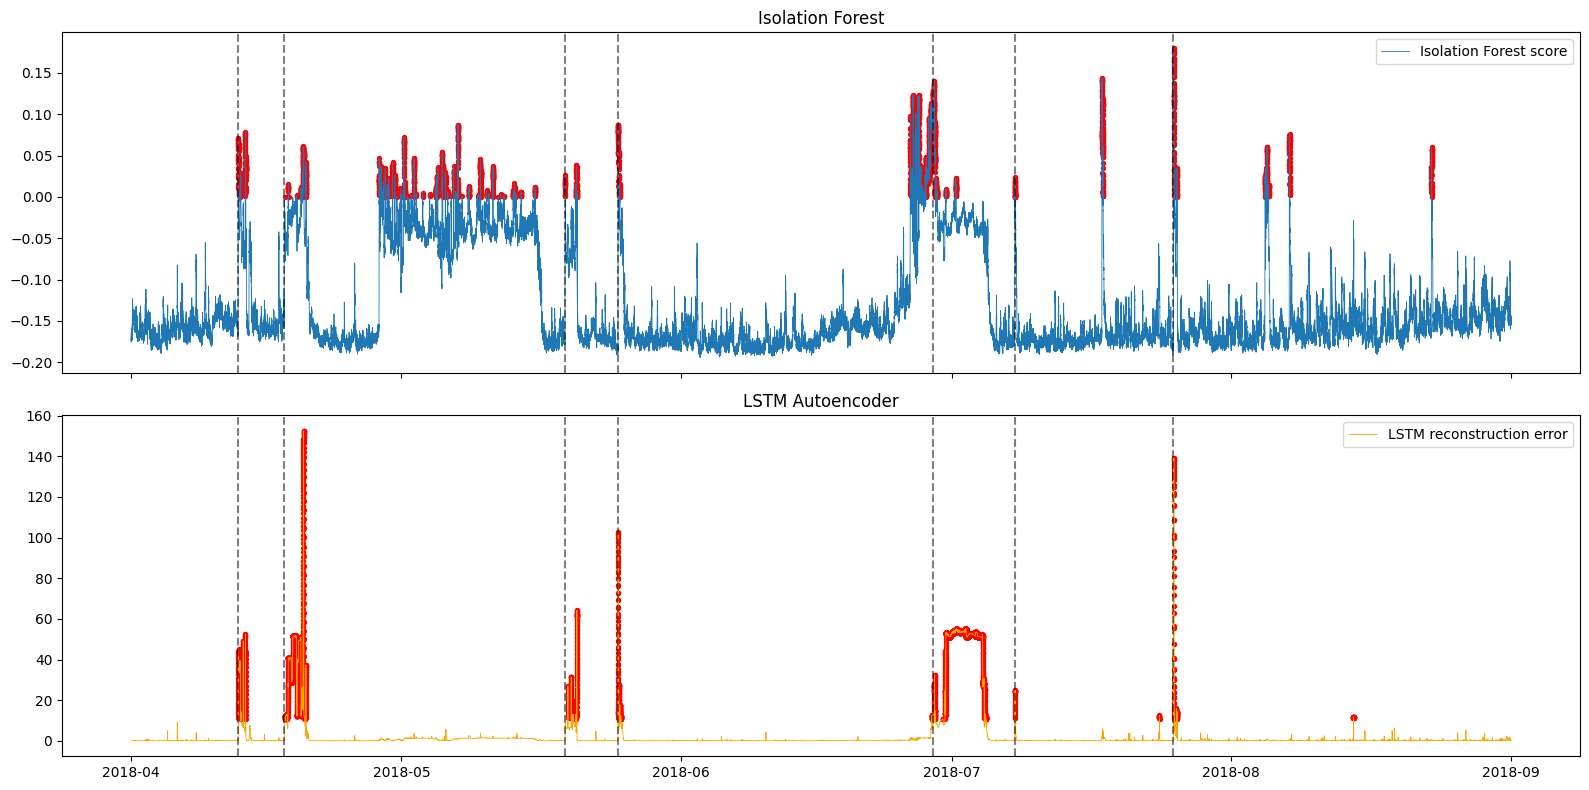

In [ ]:
#step 6- Combined visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(comparison["timestamp"], comparison["iso_score"], linewidth=0.6, label="Isolation Forest score")
axes[0].scatter(comparison.loc[comparison["iso_anomaly"], "timestamp"],
                 comparison.loc[comparison["iso_anomaly"], "iso_score"], color="red", s=8)
for t in failure_times:
    axes[0].axvline(t, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("Isolation Forest")
axes[0].legend()

axes[1].plot(comparison["timestamp"], comparison["lstm_score"], linewidth=0.6, label="LSTM reconstruction error", color="orange")
axes[1].scatter(comparison.loc[comparison["lstm_anomaly"], "timestamp"],
                 comparison.loc[comparison["lstm_anomaly"], "lstm_score"], color="red", s=8)
for t in failure_times:
    axes[1].axvline(t, color="black", linestyle="--", alpha=0.5)
axes[1].set_title("LSTM Autoencoder")
axes[1].legend()

plt.tight_layout()
plt.show()